In [24]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


universe = [
    # Semiconductors / equipment / EDA
    "NVDA","AMD","AVGO","MU","AMAT","LRCX","KLAC","ADI","TXN","INTC",
    "QCOM","MRVL","NXPI","MCHP","ON","MPWR","TER","ENTG","SWKS","LSCC",
    "RMBS","QRVO","COHR","SYNA","IPGP","ALGM","CRUS","DIOD","FORM","POWI",
    "AEIS","SITM","MKSI","AMKR","ASML","TSM","SNPS","CDNS","STM",

    # Software / cloud / data / dev tools
    "MSFT","ORCL","CRM","NOW","ADBE","INTU","ADSK","DDOG","MDB","SNOW",
    "HUBS","SHOP","TEAM","GTLB","ESTC","PATH","CFLT","DOCN","AI","WK",
    "BOX","DBX","NTAP","WDAY","FICO","ROP","U","ZI","TWLO","PAYC",
    "VEEV","ANSS","MANH","BILL","PCOR","DT","APP","PLTR",

    # Cybersecurity / networking / infrastructure software
    "CRWD","PANW","FTNT","NET","ZS","OKTA","CHKP","FFIV","AKAM","CSCO",
    "ANET","GEN","QLYS","VRNS","TENB","RDWR","ATEN","NTCT","CVLT","RPD",
    "LDOS","BAH","IBM","JNPR","CIEN"
]

In [25]:
PCA_LOOKBACK = 252
N_PCA_FACTORS = 15
OU_WINDOW = 60

ENTRY_THRESHOLD = 1.25
LONG_EXIT_THRESHOLD = 0.50
SHORT_EXIT_THRESHOLD = 0.75
KAPPA_MIN = 8.4

TRANSACTION_COST_BPS = 5
TRANSACTION_COST = TRANSACTION_COST_BPS / 10000

In [26]:
# Load Prices
print(f"Number of tickers in universe: {len(universe)}")

start_date = "2018-01-01"
end_date = None  # use latest available date

raw = yf.download(
    tickers=universe,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

# with auto_adjust=True, use Close
prices = raw["Close"].copy()

# sort dates and columns
prices = prices.sort_index()
prices = prices.reindex(sorted(prices.columns), axis=1)

# drop columns that are completely missing
prices = prices.dropna(axis=1, how="all")
min_obs = 252
mask = prices.notna().sum() >= min_obs
prices = prices.loc[:, mask]

Number of tickers in universe: 102


$JNPR: possibly delisted; no timezone found
$ZI: possibly delisted; no timezone found
$ANSS: possibly delisted; no timezone found

3 Failed downloads:
['JNPR', 'ZI', 'ANSS']: possibly delisted; no timezone found


In [27]:
# Compute Daily Returns

returns = prices.pct_change(fill_method=None)

In [28]:
# Build Rolling 1 Year windows
valid_dates = returns.index[PCA_LOOKBACK:]
print("Number of trading days:", len(returns))
print("Number of valid PCA dates:", len(valid_dates))
print("First PCA date:", valid_dates[0])

Number of trading days: 2071
Number of valid PCA dates: 1819
First PCA date: 2019-01-03 00:00:00


In [29]:
# Build rolling window index + precompute arrays

window = PCA_LOOKBACK

# integer positions where we can run PCA
valid_pos = np.arange(window, len(returns.index))

# matching dates, just for output / plotting
valid_dates = returns.index[valid_pos]

# precompute once
returns_np = returns.to_numpy()
returns_filled_np = returns.fillna(0.0).to_numpy()
dates_np = returns.index.to_numpy()
col_names = returns.columns.to_numpy()
col_index_map = {col: i for i, col in enumerate(col_names)}

print("Number of trading days:", len(returns))
print("Number of valid PCA dates:", len(valid_dates))
print("First PCA date:", valid_dates[0])

Number of trading days: 2071
Number of valid PCA dates: 1819
First PCA date: 2019-01-03 00:00:00


In [31]:
# =========================
# BASELINE BACKTEST
# =========================

pnl_series = []
turnover_series = []
active_count_series = []

# NEW
long_count_series = []
short_count_series = []

# persistent state
positions = {}        # stock -> +1 or -1
weights_prev = {}     # stock -> portfolio weight

for i in valid_pos:

    # ---------------------------------
    # 1) Build rolling PCA factor model
    # ---------------------------------
    window_slice = returns_np[i - PCA_LOOKBACK + 1 : i + 1, :]
    valid_mask = ~np.isnan(window_slice).any(axis=0)

    if valid_mask.sum() < N_PCA_FACTORS + 1:
        pnl_series.append(0.0)
        turnover_series.append(0.0)
        active_count_series.append(0)
        long_count_series.append(0)
        short_count_series.append(0)
        continue

    window_data = window_slice[:, valid_mask]
    valid_col_idx = np.where(valid_mask)[0]
    valid_col_names = col_names[valid_col_idx]

    mu = np.mean(window_data, axis=0)
    sigma = np.std(window_data, axis=0, ddof=1)

    sigma_mask = np.isfinite(sigma) & (sigma > 0)
    window_data = window_data[:, sigma_mask]
    sigma = sigma[sigma_mask]
    valid_col_idx = valid_col_idx[sigma_mask]
    valid_col_names = valid_col_names[sigma_mask]

    if window_data.shape[1] < N_PCA_FACTORS + 1:
        pnl_series.append(0.0)
        turnover_series.append(0.0)
        active_count_series.append(0)
        long_count_series.append(0)
        short_count_series.append(0)
        continue

    Y = (window_data - mu[sigma_mask]) / sigma

    corr = np.corrcoef(Y, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(corr)
    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx]

    V = eigvecs[:, :N_PCA_FACTORS]
    Q = V / sigma[:, None]

    F = window_data @ Q

    reg_window = window_data[-OU_WINDOW:, :]
    F_reg = F[-OU_WINDOW:, :]

    # ---------------------------------
    # 2) Estimate OU objects
    # ---------------------------------
    m_values = {}
    sigma_eq_values = {}
    s_values = {}

    X_factor = sm.add_constant(F_reg, has_constant="add")
    beta_dict = {}

    for j, stock in enumerate(valid_col_names):

        y = reg_window[:, j]
        model = sm.OLS(y, X_factor).fit()
        betas = model.params[1:]   # exclude intercept
        beta_dict[stock] = betas
        resid = model.resid
        X_series = np.cumsum(resid)

        X_lag = X_series[:-1]
        X_now = X_series[1:]

        if len(X_lag) < 10:
            continue

        X_reg = sm.add_constant(X_lag, has_constant="add")
        ar = sm.OLS(X_now, X_reg).fit()

        a = ar.params[0]
        b = ar.params[1]

        if not (0 < b < 1):
            continue

        kappa = -np.log(b) * 252
        if kappa <= KAPPA_MIN:
            continue

        zeta = ar.resid
        zeta_var = np.var(zeta, ddof=1)
        sigma_eq = np.sqrt(zeta_var / (1 - b**2))

        if not np.isfinite(sigma_eq) or sigma_eq <= 0:
            continue

        m = a / (1 - b)

        m_values[stock] = m
        sigma_eq_values[stock] = sigma_eq

    # ---------------------------------
    # EMPTY CASE
    # ---------------------------------
    if len(m_values) == 0:
        target_weights = {}

        turnover = sum(
            abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
            for n in set(weights_prev) | set(target_weights)
        )

        trading_cost = TRANSACTION_COST * turnover

        pnl_series.append(-trading_cost)
        turnover_series.append(turnover)
        active_count_series.append(0)
        long_count_series.append(0)
        short_count_series.append(0)

        positions = {}
        weights_prev = {}
        continue

    # ---------------------------------
    # 3) s-score
    # ---------------------------------
    m_bar = np.mean(list(m_values.values()))

    for stock in m_values.keys():
        m_adj = m_values[stock] - m_bar
        s = -m_adj / sigma_eq_values[stock]
        s_values[stock] = s

    # ---------------------------------
    # 4) positions
    # ---------------------------------
    new_positions = positions.copy()

    for stock in list(new_positions.keys()):
        if stock not in s_values:
            new_positions.pop(stock)

    for stock, s in s_values.items():
        pos = new_positions.get(stock, 0)

        if pos == 0:
            if s < -ENTRY_THRESHOLD:
                new_positions[stock] = 1
            elif s > ENTRY_THRESHOLD:
                new_positions[stock] = -1

        elif pos == 1 and s > -LONG_EXIT_THRESHOLD:
            new_positions.pop(stock)

        elif pos == -1 and s < SHORT_EXIT_THRESHOLD:
            new_positions.pop(stock)

    positions = new_positions

    # ---------------------------------
    # 5) FACTOR-NEUTRAL BANG-BANG PORTFOLIO
    # ---------------------------------
    longs = [s for s, p in positions.items() if p == 1]
    shorts = [s for s, p in positions.items() if p == -1]

    target_weights = {}

    active_names = longs + shorts
    n_active = len(active_names)

    if n_active > 0:

        # equal notional (bang-bang)
        w = 1.0 / n_active

        # --- STOCK LEGS ---
        for stock in longs:
            target_weights[stock] = +w

        for stock in shorts:
            target_weights[stock] = -w

        # --- FACTOR HEDGE ---
        factor_exposure = np.zeros(N_PCA_FACTORS)

        for stock in active_names:
            beta = beta_dict.get(stock)
            if beta is None:
                continue

            sign = target_weights[stock]
            factor_exposure += sign * beta

        for k in range(N_PCA_FACTORS):
            hedge_name = f"FACTOR_{k}"
            target_weights[hedge_name] = -factor_exposure[k]

    else:
        target_weights = {}
        positions = {}

    # track stock counts only
    long_count_series.append(len(longs))
    short_count_series.append(len(shorts))

    # ---------------------------------
    # 6) turnover
    # ---------------------------------
    turnover = sum(
        abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
        for n in set(weights_prev) | set(target_weights)
    )

    trading_cost = TRANSACTION_COST * turnover

    # ---------------------------------
    # 7) pnl
    # ---------------------------------
    if i + 1 >= len(returns_np):
        pnl_series.append(-trading_cost)
        turnover_series.append(turnover)
        active_count_series.append(len(active_names))
        break

    next_ret = returns_np[i + 1]

    gross_pnl = 0.0

    for name, w in target_weights.items():

        # STOCK
        if name in col_index_map:
            r = next_ret[col_index_map[name]]
            if not np.isnan(r):
                gross_pnl += w * r

        # FACTOR
        elif name.startswith("FACTOR_"):
            k = int(name.split("_")[1])
            factor_ret = next_ret[valid_col_idx] @ Q[:, k]
            gross_pnl += w * factor_ret

    net_pnl = gross_pnl - trading_cost

    pnl_series.append(net_pnl)
    turnover_series.append(turnover)
    active_count_series.append(len(active_names))

    weights_prev = target_weights.copy()

# =========================
# OUTPUT
# =========================
out_dates = valid_dates[:len(pnl_series)]

pnl_series = pd.Series(pnl_series, index=out_dates)
turnover_series = pd.Series(turnover_series, index=out_dates)
active_count_series = pd.Series(active_count_series, index=out_dates)

long_count_series = pd.Series(long_count_series, index=out_dates)
short_count_series = pd.Series(short_count_series, index=out_dates)

In [32]:
# =========================
# PERFORMANCE + POSITION METRICS
# =========================

ret = pnl_series.copy()

# ----- BASIC -----
mean_daily = ret.mean()
std_daily = ret.std()

ann_factor = 252
mean_annual = mean_daily * ann_factor
vol_annual = std_daily * np.sqrt(ann_factor)

sharpe = mean_annual / vol_annual if vol_annual > 0 else np.nan

# ----- EQUITY CURVE -----
cum_returns = (1 + ret).cumprod()

running_max = cum_returns.cummax()
drawdown = cum_returns / running_max - 1
max_dd = drawdown.min()

calmar = mean_annual / abs(max_dd) if max_dd != 0 else np.nan

# ----- TRADE QUALITY -----
win_rate = (ret > 0).mean()
avg_win = ret[ret > 0].mean()
avg_loss = ret[ret < 0].mean()

gross_profit = ret[ret > 0].sum()
gross_loss = ret[ret < 0].sum()
profit_factor = abs(gross_profit / gross_loss) if gross_loss != 0 else np.nan

# ----- POSITION STATS -----
avg_longs = long_count_series.mean()
avg_shorts = short_count_series.mean()
avg_positions = active_count_series.mean()

long_short_ratio = avg_longs / avg_shorts if avg_shorts > 0 else np.nan
pct_days_active = (active_count_series > 0).mean()

# ----- TURNOVER / ACTIVITY -----
avg_turnover = turnover_series.mean()
pct_trading_days = (turnover_series > 0).mean()

# ----- PRINT -----



========== BACKTEST REPORT ==========

---- PERFORMANCE ----
Annual Return     : -0.0076
Annual Vol        : 0.0647
Sharpe Ratio      : -0.1178
Max Drawdown      : -0.1708
Calmar Ratio      : -0.0446

---- TRADE QUALITY ----
Win Rate          : 0.4964
Avg Win           : 0.00298
Avg Loss          : -0.00300
Profit Factor     : 0.9800

---- POSITION STATS ----
Avg Longs         : 17.81
Avg Shorts        : 15.00
Avg Positions     : 32.81
Long/Short Ratio  : 1.19
% Days Active     : 1.00

---- ACTIVITY ----
Avg Turnover      : 0.2922
% Trading Days    : 1.00


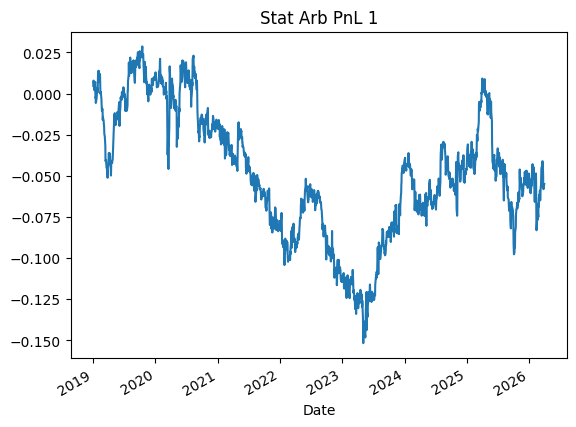

In [33]:
(pnl_series.cumsum()).plot(title="Stat Arb PnL 1")

print("\n========== BACKTEST REPORT ==========\n")

print("---- PERFORMANCE ----")
print(f"Annual Return     : {mean_annual:.4f}")
print(f"Annual Vol        : {vol_annual:.4f}")
print(f"Sharpe Ratio      : {sharpe:.4f}")
print(f"Max Drawdown      : {max_dd:.4f}")
print(f"Calmar Ratio      : {calmar:.4f}")

print("\n---- TRADE QUALITY ----")
print(f"Win Rate          : {win_rate:.4f}")
print(f"Avg Win           : {avg_win:.5f}")
print(f"Avg Loss          : {avg_loss:.5f}")
print(f"Profit Factor     : {profit_factor:.4f}")

print("\n---- POSITION STATS ----")
print(f"Avg Longs         : {avg_longs:.2f}")
print(f"Avg Shorts        : {avg_shorts:.2f}")
print(f"Avg Positions     : {avg_positions:.2f}")
print(f"Long/Short Ratio  : {long_short_ratio:.2f}")
print(f"% Days Active     : {pct_days_active:.2f}")

print("\n---- ACTIVITY ----")
print(f"Avg Turnover      : {avg_turnover:.4f}")
print(f"% Trading Days    : {pct_trading_days:.2f}")